In [1]:
import numpy as np
import scipp as sc
import MDAnalysis as mda
from MDAnalysis.coordinates.memory import MemoryReader
from kinisi.analyze import DiffusionAnalyzer
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
base = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi"

out = base / "data"

out.mkdir(parents=True, exist_ok=True)

In [3]:
def walk(atoms, timesteps, jump_size, seed):
    possible_moves = np.zeros((6, 3))
    j = 0


    for i in range(0, 6, 2):
        possible_moves[i, j] = jump_size
        possible_moves[i + 1, j] = -jump_size
        j += 1

        
    choices = seed.choice(6, size=(atoms, timesteps))
    steps = possible_moves[choices]
    return np.cumsum(steps, axis=1)

In [4]:
def raw_covariance(d):
    da = d.dg['da']
    variances = da.data.variances
    n_samples = da.coords['n_samples'].values
    n = variances.size
    cov = np.zeros((n, n))



    for i in range(n):
        for j in range(i, n):
            ratio = n_samples[i] / n_samples[j]
            cov[i, j] = ratio * variances[i]
            cov[j, i] = cov[i, j]
    regime = d.diff.diff_regime

    
    return cov[regime:, regime:]

In [5]:

def run_one(seed, atoms, length, jump):
    rng = np.random.RandomState(seed)
    steps = walk(atoms, length, jump, rng)
    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))


    u = mda.Universe.empty(steps.shape[0], trajectory=True)

    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])

    u.add_TopologyAttr('type', ['A'] * steps.shape[0])
    
    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)



    d = DiffusionAnalyzer.from_universe(u, time_step=1.0 * sc.Unit('s'), step_skip=1,
                                        distance_unit=sc.Unit('m'), specie='A',
                                        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                                        stop=length * sc.Unit('s'), num=int((length - 2))),progress=False)
    


    d.diffusion(2 * sc.Unit('s'), progress=False)

    return raw_covariance(d)

In [6]:
length = int(2 ** 7)

jump = np.sqrt(6)

atom_counts = [64, 256, 1024, 4096, 16384]

n_runs = 200

results = {}

for atoms in atom_counts:

    frac_neg = []

    lam_min_list = []

    for seed in tqdm(range(n_runs), desc=f"atoms={atoms}"):

        c = run_one(seed, atoms, length, jump)

        ev = np.linalg.eigvalsh(c)

        lam_min_list.append(ev[0])

        frac_neg.append(ev[0] < 0)

    frac = np.mean(frac_neg)

    med = np.median(lam_min_list)

    results[atoms] = {"frac_neg": frac, "median_lam_min": med, "lam_min": np.array(lam_min_list)}
    
    print(f"atoms {atoms:5d}: fraction negative {frac:.3f}   median lambda_min {med:8.4f}")

atoms=64:   0%|          | 0/200 [00:00<?, ?it/s]/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
atoms=64: 100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


atoms    64: fraction negative 0.905   median lambda_min -157.4770


atoms=256: 100%|██████████| 200/200 [01:18<00:00,  2.56it/s]


atoms   256: fraction negative 0.660   median lambda_min  -3.3555


atoms=1024: 100%|██████████| 200/200 [01:31<00:00,  2.20it/s]


atoms  1024: fraction negative 0.275   median lambda_min   0.0003


atoms=4096: 100%|██████████| 200/200 [02:22<00:00,  1.40it/s]


atoms  4096: fraction negative 0.090   median lambda_min   0.0001


atoms=16384: 100%|██████████| 200/200 [05:13<00:00,  1.57s/it]

atoms 16384: fraction negative 0.005   median lambda_min   0.0000


  64 -> 256 (4x atoms): frac neg 0.905 -> 0.660
  256 -> 1024 (4x atoms): frac neg 0.660 -> 0.275
  1024 -> 4096 (4x atoms): frac neg 0.275 -> 0.090
  4096 -> 16384 (4x atoms): frac neg 0.090 -> 0.005


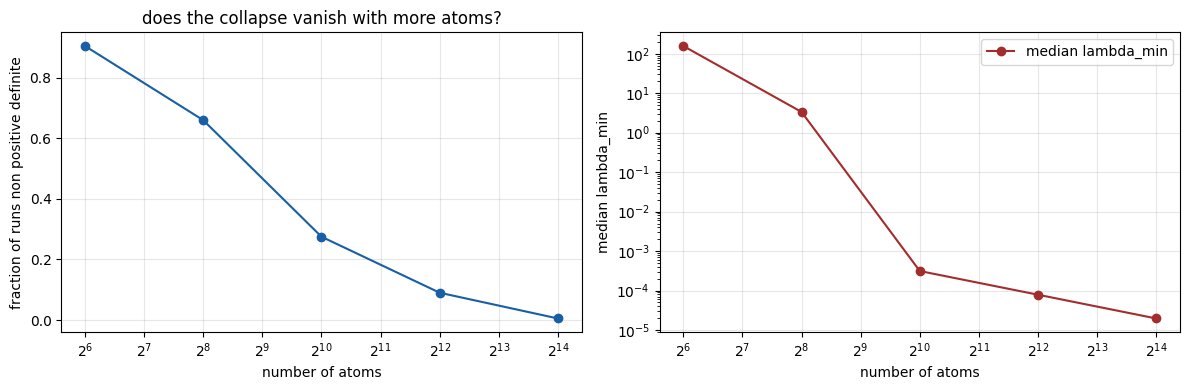

In [22]:
atoms_arr = np.array(atom_counts, dtype=float)

fracs = np.array([results[a]["frac_neg"] for a in atom_counts])

meds = np.array([results[a]["median_lam_min"] for a in atom_counts])


for i in range(1, len(atom_counts)):
    atom_ratio = atoms_arr[i] / atoms_arr[i-1]
    print(f"  {atom_counts[i-1]} -> {atom_counts[i]} ({atom_ratio:.0f}x atoms): "
          f"frac neg {fracs[i-1]:.3f} -> {fracs[i]:.3f}")




fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(atoms_arr, fracs, marker="o", color="#185fa5")
ax[0].set_xscale("log", base=2)
ax[0].set_xlabel("number of atoms")
ax[0].set_ylabel("fraction of runs non positive definite")
ax[0].set_title("does the collapse vanish with more atoms?")
ax[0].grid(alpha=0.3)



ax[1].plot(atoms_arr, np.abs(meds), marker="o", color="#a32d2d", label="median lambda_min")

ax[1].set_xscale("log", base=2)
ax[1].set_yscale("log")
ax[1].set_xlabel("number of atoms")
ax[1].set_ylabel("median lambda_min")
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

  atoms     64: frac neg 0.905   median lambda_min -157.4770
  atoms    256: frac neg 0.660   median lambda_min   -3.3555
  atoms   1024: frac neg 0.275   median lambda_min    0.0003
  atoms   4096: frac neg 0.090   median lambda_min    0.0001
  atoms  16384: frac neg 0.005   median lambda_min    0.0000


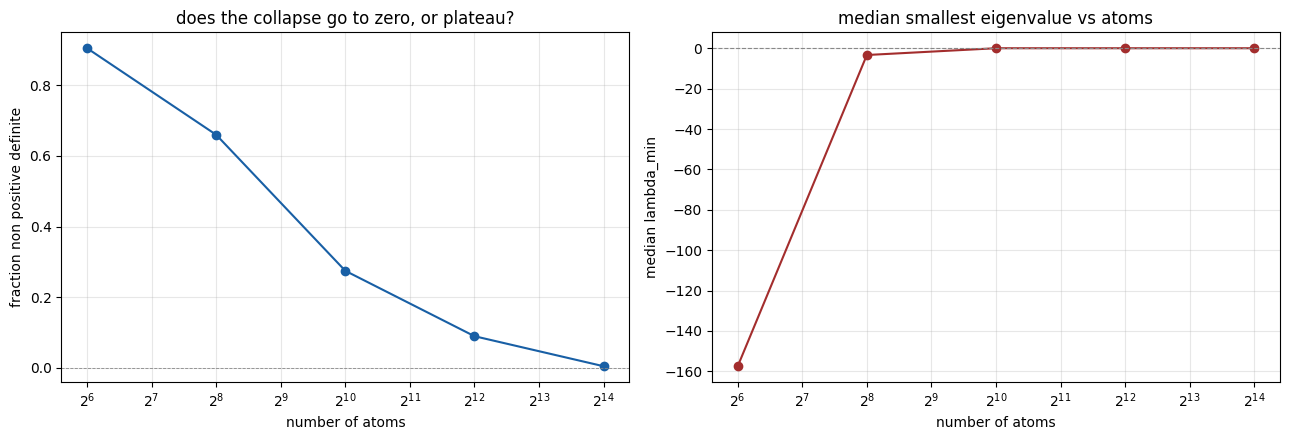

In [19]:
all_atoms = sorted(results.keys())

atoms_arr = np.array(all_atoms, dtype=float)

fracs = np.array([results[a]["frac_neg"] for a in all_atoms])

meds = np.array([results[a]["median_lam_min"] for a in all_atoms])


for a in all_atoms:
    print(f"  atoms {a:6d}: frac neg {results[a]['frac_neg']:.3f}   median lambda_min {results[a]['median_lam_min']:9.4f}")





fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(atoms_arr, fracs, marker="o", color="#185fa5")
ax[0].set_xscale("log", base=2)
ax[0].set_xlabel("number of atoms")
ax[0].set_ylabel("fraction non positive definite")
ax[0].set_title("does the collapse go to zero, or plateau?")
ax[0].axhline(0, color="#888", linewidth=0.6, linestyle="--")
ax[0].grid(alpha=0.3)




ax[1].plot(atoms_arr, meds, marker="o", color="#a32d2d")
ax[1].axhline(0, color="#888", linewidth=0.8, linestyle="--")
ax[1].set_xscale("log", base=2)
ax[1].set_xlabel("number of atoms")
ax[1].set_ylabel("median lambda_min")
ax[1].set_title("median smallest eigenvalue vs atoms")
ax[1].grid(alpha=0.3)




plt.tight_layout()
plt.show()

In [ ]:
captured = {}

for atoms in atom_list:
    covs, vars_ = [], []


    for seed in range(n_capture):
        cov, var, nsamp, times = run_capture(seed, length, length, jump) if False else run_capture(seed, atoms, length, jump)
        covs.append(cov)
        vars_.append(var)



    captured[atoms] = {"cov0": covs[0],
                       "var_mean": np.mean(vars_, axis=0),
                       "nsamp": nsamp,
                       "times": times}
    
    
    print(f"captured atoms={atoms}")

captured atoms=64
captured atoms=256
captured atoms=1024
captured atoms=4096
captured atoms=16384


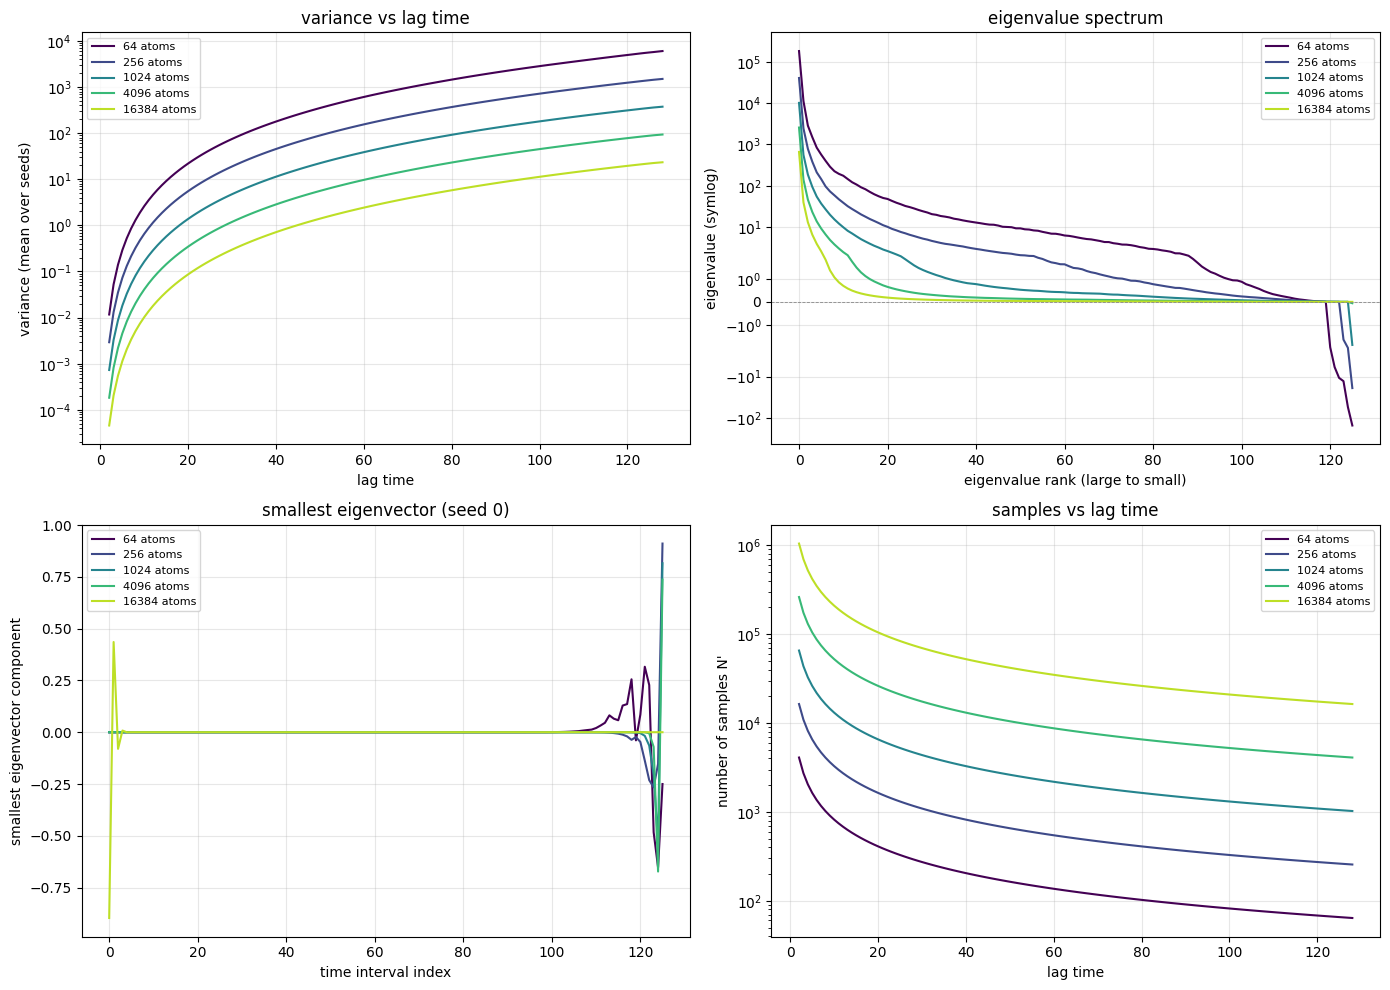

In [ ]:
colors = plt.cm.viridis(np.linspace(0, 0.9, len(atom_list)))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))



ax = axes[0, 0]
for c, atoms in zip(colors, atom_list):
    times = captured[atoms]["times"]
    var = captured[atoms]["var_mean"]
    ax.plot(times, var, color=c, label=f"{atoms} atoms")
ax.set_yscale("log")
ax.set_xlabel("lag time")
ax.set_ylabel("variance (mean over seeds)")
ax.set_title("variance vs lag time")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)




ax = axes[0, 1]
for c, atoms in zip(colors, atom_list):
    ev = np.linalg.eigvalsh(captured[atoms]["cov0"])
    ax.plot(np.sort(ev)[::-1], color=c, label=f"{atoms} atoms")
ax.set_yscale("symlog")
ax.axhline(0, color="#888", linewidth=0.6, linestyle="--")
ax.set_xlabel("eigenvalue rank (large to small)")
ax.set_ylabel("eigenvalue (symlog)")
ax.set_title("eigenvalue spectrum")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)




ax = axes[1, 0]
for c, atoms in zip(colors, atom_list):
    vals, vecs = np.linalg.eigh(captured[atoms]["cov0"])
    ax.plot(vecs[:, 0], color=c, label=f"{atoms} atoms")
ax.set_xlabel("time interval index")
ax.set_ylabel("smallest eigenvector component")
ax.set_title("smallest eigenvector (seed 0)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)





ax = axes[1, 1]
for c, atoms in zip(colors, atom_list):
    times = captured[atoms]["times"]
    nsamp = captured[atoms]["nsamp"]
    ax.plot(times, nsamp, color=c, label=f"{atoms} atoms")
ax.set_yscale("log")
ax.set_xlabel("lag time")
ax.set_ylabel("number of samples N'")
ax.set_title("samples vs lag time")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Hey Andrew - Suspect B looks conclusive.

Atom sweep (64 -> 16384, 200 runs each), fraction of raw matrices that are non positive definite:

atoms=64: 100%|██████████| 200/200 [01:14<00:00,  2.69it/s]
atoms    64: fraction negative 0.905   median lambda_min -157.4770

atoms=256: 100%|██████████| 200/200 [01:18<00:00,  2.56it/s]
atoms   256: fraction negative 0.660   median lambda_min  -3.3555

atoms=1024: 100%|██████████| 200/200 [01:31<00:00,  2.20it/s]
atoms  1024: fraction negative 0.275   median lambda_min   0.0003

atoms=4096: 100%|██████████| 200/200 [02:22<00:00,  1.40it/s]
atoms  4096: fraction negative 0.090   median lambda_min   0.0001

atoms=16384: 100%|██████████| 200/200 [05:13<00:00,  1.57s/it]
atoms 16384: fraction negative 0.005   median lambda_min   0.0000

The collapse goes to zero as atoms increase (median lambda_min climbs from -157 back up to the true  0), rather than plateauing.In our Suspect A test for 128 count it gave lambda_min 81% of negative which is between the 64 and 256 N atoms.

That's sample noise, more samples at long lag times cleans up the variance so the near singular eigenvalue stops being tipped negative and it rules out D (floating point), since precision error wouldn't improve with more atoms.

So across all four: A sets up the fragile structure but isn't the trigger, C isn't independent, and B (long time sample noise) is the driver - which is just the regime where shrinkage reconditioning is the right fix. 

this shows B dominates, not that D is exactly zero, a float32/float64 test would close it's worth doing.

Fixing the Suspect B is next step.